## Loading libraries

In [2]:
#pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [3]:
# ============================================================
# STEP -1 - Importing Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from tqdm.auto import tqdm
import time
from lightgbm import LGBMClassifier
import shap


## Step 0. Loading the Dataset

In [4]:
# ============================================================
# STEP 0 - Loading the Dataset
# ============================================================

##df = pd.read_sas("/Users/fatimaiqbal/Desktop/Data Mining/LLCP2023.XPT", format="xport", encoding="latin1")

##ozlem version
##df = pd.read_sas(r'C:\Users\olcer\OneDrive\Desktop\Data Mining Project\LLCP2023XPT\LLCP2023.XPT')

## Muhammad version
zip_path = '/content/LLCP2023.XPT.zip'
sas_filename = 'LLCP2023.XPT'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(sas_filename) as f:
        df = pd.read_sas(f, format="xport", encoding="latin1")

df.shape

(433323, 350)

In [5]:
df['_BMI5'].describe()

,_BMI5
count,392788.000000
mean,2847.928783
std,654.197490
min,1202.000000
25%,2410.000000
50%,2740.000000
75%,3162.000000
max,9984.000000


## STEP 1 - Column Selection and STEP 2 - Duplicate Removal

In [6]:

#  2023 data

# ============================================================
# STEP 1 - Column Selection
# ============================================================
cols = ['SEQNO', '_PSU', '_STATE', 'QSTVER', 'QSTLANG', 'DIABETE4', '_RFHYPE6', 'TOLDHI3', '_CHOLCH3',
        '_BMI5', '_RFBMI5', 'SMOKE100', '_SMOKER3', 'CVDSTRK3', '_MICHD', '_TOTINDA',
        '_RFDRHV8', '_HLTHPL1', 'MEDCOST1', 'GENHLTH', 'MENTHLTH',
        'PHYSHLTH', 'DIFFWALK', 'SEXVAR', '_AGEG5YR', 'EDUCA', 'INCOME3',
        'ADDEPEV3', 'HAVARTH4', 'CHCKDNY2']

df = df[cols]
print(f"Step 1 - After column selection: {df.shape}")

# ============================================================
# STEP 2 - Duplicate Removal
# ============================================================
before_dedup = len(df)
df = df.drop_duplicates(subset=['SEQNO', 'QSTVER', 'QSTLANG', '_STATE'])
after_dedup = len(df)
print(f"\nStep 2 - Duplicates removed: {before_dedup - after_dedup}")
print(f"After deduplication: {df.shape}")

Step 1 - After column selection: (433323, 30)

Step 2 - Duplicates removed: 0
After deduplication: (433323, 30)


## STEP 3 - Missing Value Removal

In [7]:
# ============================================================
# STEP 3 - Missing Value Removal
# ============================================================
print(f"\nStep 3 - Row reduction per column:")
temp_df = df.copy()
missing_cols = df.columns[df.isnull().any()].tolist()
for col in missing_cols:
    before = len(temp_df)
    temp_df = temp_df.dropna(subset=[col])
    after = len(temp_df)
    if before - after > 0:
        print(f"  Dropping NaN in {col}: -{before - after} rows (remaining: {after})")

df = df.dropna()
print(f"\nStep 4 - Final shape after dropna: {df.shape}")


Step 3 - Row reduction per column:
  Dropping NaN in DIABETE4: -5 rows (remaining: 433318)
  Dropping NaN in TOLDHI3: -51809 rows (remaining: 381509)
  Dropping NaN in _BMI5: -33917 rows (remaining: 347592)
  Dropping NaN in SMOKE100: -5626 rows (remaining: 341966)
  Dropping NaN in CVDSTRK3: -1 rows (remaining: 341965)
  Dropping NaN in _MICHD: -3096 rows (remaining: 338869)
  Dropping NaN in GENHLTH: -1 rows (remaining: 338868)
  Dropping NaN in EDUCA: -1 rows (remaining: 338867)

Step 4 - Final shape after dropna: (338867, 30)


## STEP 4 -  Value Recoding and Outlier Management
## And Establishing proxies for risk groups and diseases

In [8]:
# ============================================================
# STEP 4 -  Value Recoding and Outlier Management
# ============================================================
print("\nStep 4 - Outlier management and value recoding...")

# DIABETE4 - target variable
# 1 = Diabetic, 4 = Pre-diabetes -> keep as 1
# 2 = Pregnant only, 3 = No -> keep as 0
# 7, 9 = Don't know/Refused -> drop

df = df[~df['DIABETE4'].isin([7.0, 9.0])]  # drop unknowns first
df['DIABETE4'] = (df['DIABETE4'].isin([1.0, 4.0])).astype(int)  # 1 if diabetic, 0 otherwise

# _RFHYPE6 - high blood pressure
## Yes 1, No 2 -> Yes 1, No 0
df['_RFHYPE6'] = df['_RFHYPE6'].replace({1:0, 2:1})
df = df[df['_RFHYPE6'] != 9]

# TOLDHI3 - told high cholesterol
## No, 2 -> No, 0
df['TOLDHI3'] = df['TOLDHI3'].replace({2:0})
df = df[~df['TOLDHI3'].isin([7, 9])]

# _CHOLCH3 - cholesterol check
#Did not have cholesterol check 2, had never had cholesterol check 3 -> No 0
df['_CHOLCH3'] = df['_CHOLCH3'].replace({2:0, 3:0})
df = df[df['_CHOLCH3'] != 9]

# _BMI5 - BMI (divide by 100)
df['_BMI5'] = df['_BMI5'].div(100).round(0)

# _RFBMI5 - overweight/obese flag
## 12 < BMI <25,1 --> No,0
## BMI >= 25,2 --> Yes,1
df['_RFBMI5'] = df['_RFBMI5'].replace({1:0, 2:1})
df = df[df['_RFBMI5'] != 9]

# SMOKE100 - smoked 100
# Smoked 100 cigarettes in lifetime: No, 2 -> No, 0
df['SMOKE100'] = df['SMOKE100'].replace({2:0})
df = df[~df['SMOKE100'].isin([7, 9])]

# _SMOKER3 - smoker status (keep ordinal 1-4)
#Current Smoker - smokes everyday, 1
#Current Smoker - smokes some days, 2
#Former Smoker, 3
#Never Smoker, 4
df = df[df['_SMOKER3'] != 9]

# CVDSTRK3 - ever had stroke
# No, 2 -> No, 0
df['CVDSTRK3'] = df['CVDSTRK3'].replace({2:0})
df = df[~df['CVDSTRK3'].isin([7, 9])]

# _MICHD - coronary heart disease
# No, 2 -> No, 0
df['_MICHD'] = df['_MICHD'].replace({2:0})

# _TOTINDA - physical activity
# No, 2 -> No, 0
df['_TOTINDA'] = df['_TOTINDA'].replace({2:0})
df = df[df['_TOTINDA'] != 9]

# _RFDRHV8 - heavy drinker
# No,1 -> No,0
# Yes,2 -> Yes,1
df['_RFDRHV8'] = df['_RFDRHV8'].replace({1:0, 2:1})
df = df[df['_RFDRHV8'] != 9]

# _HLTHPL1 - health insurance
# No, 2 -> No, 0
df['_HLTHPL1'] = df['_HLTHPL1'].replace({2:0})
df = df[df['_HLTHPL1'] != 9]

# MEDCOST1 - could not see doctor due to cost
# No, 2 -> No, 0
df['MEDCOST1'] = df['MEDCOST1'].replace({2:0})
df = df[~df['MEDCOST1'].isin([7, 9])]

# GENHLTH - general health (keep ordinal 1-5)
# 1 Good to 5 Poor, 7 Don't know, 9 Refused
df = df[~df['GENHLTH'].isin([7, 9])]

# MENTHLTH - days mental health not good
# 88 None, 77 Don't know, 99 Refused
df['MENTHLTH'] = df['MENTHLTH'].replace({88:0})
df = df[~df['MENTHLTH'].isin([77, 99])]

# PHYSHLTH - days physical health not good
# 88 None, 77 Don't know, 99 Refused
df['PHYSHLTH'] = df['PHYSHLTH'].replace({88:0})
df = df[~df['PHYSHLTH'].isin([77, 99])]

# DIFFWALK - difficulty walking
# No, 2 -> No, 0
df['DIFFWALK'] = df['DIFFWALK'].replace({2:0})
df = df[~df['DIFFWALK'].isin([7, 9])]

# SEXVAR - sex (1=Male, 2=Female)
# Female, 2 -> Female, 0
df['SEXVAR'] = df['SEXVAR'].replace({2:0})

# _AGEG5YR - age group (keep ordinal 1-13)
df = df[df['_AGEG5YR'] != 14]

# EDUCA - education (keep ordinal 1-6)
df = df[df['EDUCA'] != 9]

# INCOME3 - income (keep ordinal 1-11)
df = df[~df['INCOME3'].isin([77, 99])]

# ADDEPEV3 - depression
# No, 2 -> No, 0
df['ADDEPEV3'] = df['ADDEPEV3'].replace({2:0})
df = df[~df['ADDEPEV3'].isin([7, 9])]

# HAVARTH4 - arthritis
# No, 2 -> No, 0
df['HAVARTH4'] = df['HAVARTH4'].replace({2:0})
df = df[~df['HAVARTH4'].isin([7, 9])]

# CHCKDNY2 - kidney disease
# No, 2 -> No, 0
df['CHCKDNY2'] = df['CHCKDNY2'].replace({2:0})
df = df[~df['CHCKDNY2'].isin([7, 9])]


# ============================================================
# STEP 4.5 - Establishing proxies for risk groups and diseases
# ============================================================


# 1. Metabolic Syndrome (MetS) Proxy
# Condition: Has the three other of the four syntoms of a metabolic syndrome (diabetis is the forth syndrome)

is_obese = df['_RFBMI5'] >= 1
has_htn = df['_RFHYPE6'] == 1
has_chol = df['TOLDHI3'] == 1

mets_score = is_obese.astype(int) + has_htn.astype(int) + has_chol.astype(int)

# Set flag to 1 if score = 3, otherwise 0
df['Metabolic_Syndrome'] = mets_score


# 2. High Cardiovascular Risk (ASCVD) Proxy
 # Condition: History of heart attack/stroke OR dangerous combinations

hist_cvd = (df['_MICHD'] == 1) | (df['CVDSTRK3'] == 1)

# 1 (Everyday) and 2 (Some days) represent current smokers
is_current_smoker = df['_SMOKER3'].isin([1, 2])

htn_chol_smoke = (df['_RFHYPE6'] == 1) & (df['TOLDHI3'] == 1) & is_current_smoker

 # If any conditions are met
high_risk_condition = hist_cvd | htn_chol_smoke
df['High_CVD_Risk_Profile'] = high_risk_condition.astype(int)


# 3. Chronic Comorbidity Burden (CCI Proxy)
# Sum of the binary indicators of the 4 major organ diseases, excluding diabetis

comorbidity_cols = [
        '_MICHD',
        'CVDSTRK3',
        'CHCKDNY2'
    ]

df['Comorbidity_Count'] = df[comorbidity_cols].sum(axis=1)


# 4. Behavioral Risk / Healthy Lifestyle Score (AHA Proxy)
# Starts at 0, +1 for each positive factor

score_smoke = df['_SMOKER3'].isin([3, 4]).astype(int)
score_active = (df['_TOTINDA'] == 1).astype(int)
score_bmi = (df['_RFBMI5'] == 0).astype(int)
score_drink = (df['_RFDRHV8'] == 0).astype(int)

df['Healthy_Lifestyle_Score'] = score_smoke + score_active + score_bmi + score_drink

print(f"After outlier management and recoding: {df.shape}")


Step 4 - Outlier management and value recoding...
After outlier management and recoding: (259269, 34)


## STEP 5 - Rename Columns

In [9]:
# ============================================================
# STEP 5 - Rename Columns
# ============================================================
df= df.rename(columns={
    'SEQNO': 'SequenceNo',
    '_PSU': 'PSU',
    '_STATE': 'State',
    'QSTVER': 'QuestionnaireVersion',
    'QSTLANG': 'QuestionnaireLang',
    'DIABETE4': 'Diabetes',
    '_RFHYPE6': 'HighBP',
    'TOLDHI3': 'HighChol',
    '_CHOLCH3': 'CholCheck',
    '_BMI5': 'BMI',
    '_RFBMI5': 'Overweight',
    'SMOKE100': 'Smoker',
    '_SMOKER3': 'SmokerStatus',
    'CVDSTRK3': 'Stroke',
    '_MICHD': 'HeartDisease',
    '_TOTINDA': 'PhysActivity',
    '_RFDRHV8': 'HeavyAlcohol',
    '_HLTHPL1': 'HealthInsurance',
    'MEDCOST1': 'NoDocCost',
    'GENHLTH': 'GenHealth',
    'MENTHLTH': 'MentHealth',
    'PHYSHLTH': 'PhysHealth',
    'DIFFWALK': 'DiffWalking',
    'SEXVAR': 'Sex',
    '_AGEG5YR': 'AgeGroup',
    'EDUCA': 'Education',
    'INCOME3': 'Income',
    'ADDEPEV3': 'Depression',
    'HAVARTH4': 'Arthritis',
    'CHCKDNY2': 'KidneyDisease'
})

print(f"\nStep 5 - After renaming columns: {df.shape}")


Step 5 - After renaming columns: (259269, 34)


## STEP 6 - EDA

Diabetes
0    215014
1     44255
Name: count, dtype: int64
Diabetes
0    82.93
1    17.07
Name: proportion, dtype: float64


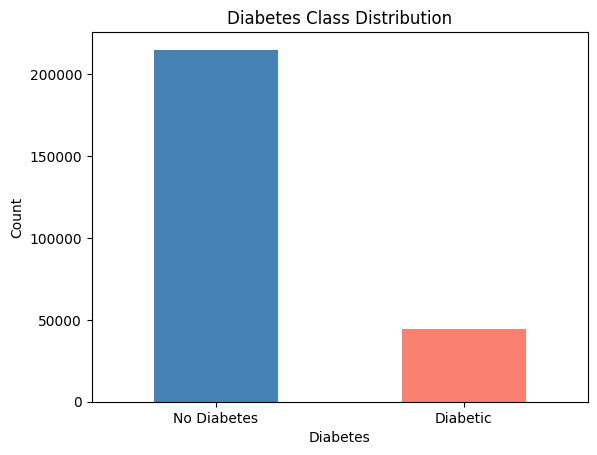

In [10]:
# ============================================================
# STEP 6 - EDA
# ============================================================


# 1. Target variable distribution
print(df['Diabetes'].value_counts())
print(df['Diabetes'].value_counts(normalize=True).mul(100).round(2))

# 2. Class imbalance plot
df['Diabetes'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Diabetes Class Distribution')
plt.xticks([0,1], ['No Diabetes',  'Diabetic'], rotation=0)
plt.ylabel('Count')
plt.show()



## STEP 7 - Boxplots for numeric variables

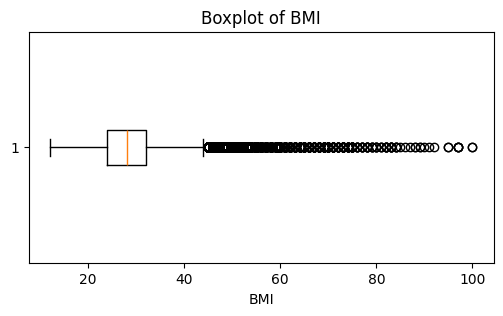

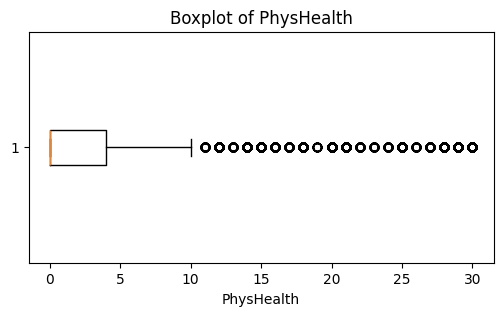

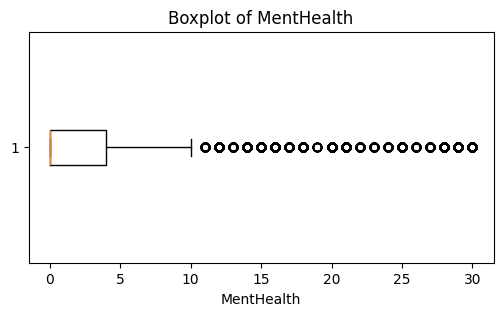

In [11]:
# ============================================================
# STEP 7 - Boxplots for numeric variables
# ============================================================
cols_for_boxplot = ["BMI", "PhysHealth", "MentHealth"]  # keep only the useful numeric ones

for col in cols_for_boxplot:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## STEP 8 - Correlation Check


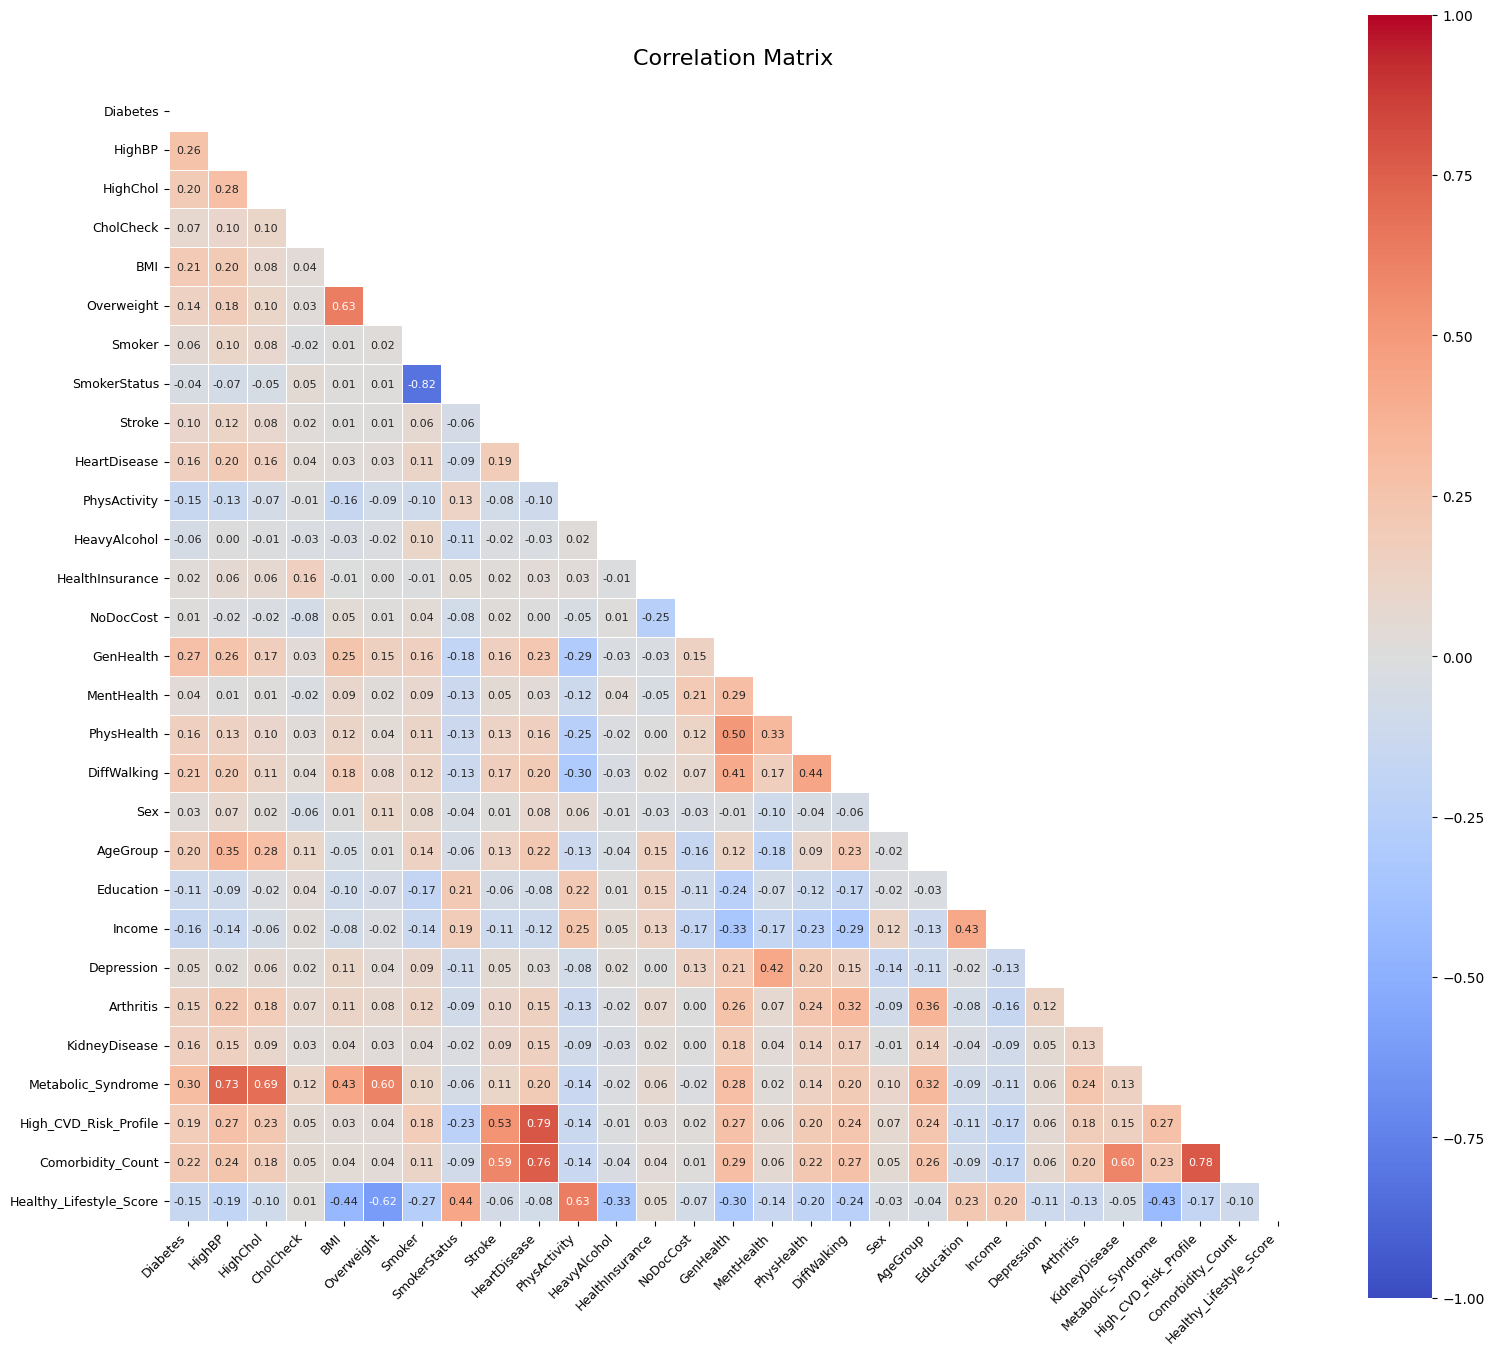

In [12]:
# ============================================================
# STEP 8 - Correlation Check
# ============================================================
#  Drop metadata columns - not needed for analysis
cols_to_drop = ['SequenceNo', 'PSU', 'State', 'QuestionnaireVersion', 'QuestionnaireLang']
df_analysis = df.drop(columns=cols_to_drop)

# Correlation matrix - cleaner version
plt.figure(figsize=(16, 14))

corr = df_analysis.corr()

# Mask upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## STEP 9 - Final Columns Selection

In [13]:
# ============================================================
# STEP 9 - Final Columns to Have
# ============================================================

target_col = ['Diabetes']
continuous_cols = ['MentHealth', 'PhysHealth']
ordinal_cols = ['GenHealth', 'AgeGroup', 'Education', 'Income', 'SmokerStatus', 'Metabolic_Syndrome', 'Comorbidity_Count', 'Healthy_Lifestyle_Score']
binary_cols = ['Overweight', 'HighBP', 'HighChol', 'Stroke',
               'HeartDisease', 'PhysActivity', 'HeavyAlcohol',
               'HealthInsurance', 'NoDocCost', 'DiffWalking', 'Sex',
               'Depression', 'Arthritis', 'KidneyDisease', 'High_CVD_Risk_Profile']

feature_col = continuous_cols + ordinal_cols + binary_cols

## STEP 10 - Splitting to test and train sets

In [14]:
# ============================================================
# STEP 10 - Splitting to test and train sets
# ============================================================
X = df[feature_col]
y = df[target_col]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, stratify = y, random_state=1)

#X_train, X_val, y_train, y_val  = train_test_split(X_train, y_train, test_size=0.25, stratify = y_train, random_state=1)

y_train = y_train.values.ravel()
#y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

print(f"Train dataframe shape: {X_train.shape}")
#print(f"Validation dataframe shape: {X_val.shape}")
print(f"Test dataframe shape: {X_test.shape}")


Train dataframe shape: (181488, 25)
Test dataframe shape: (77781, 25)


In [15]:
# ============================================================
# STEP X - checking # ============================================================


preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(), continuous_cols)
    ],
    remainder='passthrough'
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',  CatBoostClassifier(logging_level='Silent', scale_pos_weight = 3))
])

scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score, average='macro'),
        'recall': make_scorer(recall_score, average='macro'),
        'f1_macro': make_scorer(f1_score, average='macro'),
        'roc_auc': 'roc_auc'
    }




cv_results = cross_validate(clf_pipeline, X=X_train, y=y_train.ravel(), cv=5, scoring=scoring_metrics)


print(cv_results)

KeyboardInterrupt: 

## STEP 11. Nested cross validation


In [16]:
# Function for nested cross validation

def all_pipeline(X, y, dict_of_models, hyperparameters_dict, continuous_cols,
                 cv_folds_outer=4, cv_folds_inner=4):

    # 1. Define Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), continuous_cols)],
        remainder='passthrough'
    )


    # 2. Define the metrics (Now including roc_auc)
    # Note: 'roc_auc' works for binary. For multiclass, use 'roc_auc_ovr'
    scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1_macro': make_scorer(f1_score),
        'roc_auc': 'roc_auc'
    }

    results = {}

    pbar = tqdm(dict_of_models.items(), desc="Overall Progress")

    for model_name, model_obj in pbar:
        if model_name != 'Naive Bayes Complement':
          preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), continuous_cols)],
        remainder='passthrough'
                                          )
        else:
          preprocessor = ColumnTransformer(
          transformers=[('num', MinMaxScaler(), continuous_cols)],
          remainder='passthrough')

        pbar.set_description(f"Processing {model_name}")
        print(f"\n Model: {model_name}")

        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

        inner_cv = StratifiedKFold(n_splits=cv_folds_inner, shuffle=True, random_state=42)
        outer_cv = StratifiedKFold(n_splits=cv_folds_outer, shuffle=True, random_state=42)

        p_grid = hyperparameters_dict[model_name]

        # We tune the inner loop based on f1_macro or roc_auc depending on your preference
        clf = GridSearchCV(estimator=pipe, param_grid=p_grid, cv=inner_cv, scoring='f1_macro', verbose=2)

        # Outer Loop
        cv_results = cross_validate(clf, X=X, y=y.ravel(), cv=outer_cv, scoring=scoring_metrics)

        # 3. Store and Print the Results
        results[model_name] = {
            'Model': model_name,

            'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.2f})",

            'F1_Macro': f"{cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.2f})",

            'Recall': f"{cv_results['test_recall'].mean():.4f} (+- {cv_results['test_recall'].std():.2f})",

            'Precision': f"{cv_results['test_precision'].mean():.4f} (+0- {cv_results['test_precision'].std():.2f})",

            'AUC-ROC': f"{cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.2f})"

        }


        print(f"--- {model_name} Aggregated Report ---")
        print(f"Accuracy:  {results[model_name]['Accuracy']}")
        print(f"Precision: {results[model_name]['Precision']}")
        print(f"Recall:    {results[model_name]['Recall']}")
        print(f"F1-Macro:  {results[model_name]['F1_Macro']}")
        print(f"ROC-AUC:   {results[model_name]['AUC-ROC']}")

    return results

In [17]:
import warnings
# Filter out the specific LightGBM/Sklearn feature name warning
warnings.filterwarnings("ignore", message="X does not have valid feature names")


# All models and hyperparameters set
dict_of_models = {
    'Logistic Regression': LogisticRegression(max_iter=100, solver='saga'),
    'Naive Bayes Gaussian': GaussianNB(),
    'Naive Bayes Complement': ComplementNB(),
    'SVM': SGDClassifier(class_weight='balanced'),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(logging_level='Silent'),
    'LightGBM': LGBMClassifier(verbosity=-1),
    'Ada Boost': AdaBoostClassifier(),
    'Gradient Boost': HistGradientBoostingClassifier(),
    'Balanced RF': BalancedRandomForestClassifier()
}

hyperparameters_dict = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 500],
        'classifier__max_depth': [3, 5, 10]
    },
    'Naive Bayes Gaussian': {
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-5]
    },
    'Naive Bayes Complement': {
        'classifier__alpha': [0.1, 1.0, 10, 0.001]
    },
    'SVM':
        {
    'classifier__loss': ['hinge', 'log_loss'],
    'classifier__alpha': [1e-4, 1e-2, 1e-1, 1]
}
    ,
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.1, 0.3, 0.5],
        'classifier__max_depth': [3, 5, 10],
        'classifier__scale_pos_weight': [2, 3, 4]
    },
    'CatBoost': {
        'classifier__iterations': [100, 200, 500],
        'classifier__depth': [4, 6],
        'classifier__scale_pos_weight': [2, 3, 4]
    },
    'Balanced RF': {
        'classifier__n_estimators': [100, 200, 500],
        'classifier__max_depth': [3, 5, 10]
    },
    'LightGBM': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.3],
        'classifier__scale_pos_weight': [2, 3, 4],
        'classifier__max_depth': [3, 5, 10]
    },
    'Ada Boost':{
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.1, 1, 5]
    },
    'Gradient Boost':{
        'classifier__max_depth': [3, 5, 10],
        'classifier__learning_rate': [0.01, 0.1, 0.3]
    }

}

In [ ]:
# Running all models with hyperparameter selection and predefined nested cross validation in order to get stability of models

results = all_pipeline(X_train, y_train, dict_of_models, hyperparameters_dict, continuous_cols)


Overall Progress:   0%|          | 0/10 [00:00<?, ?it/s]


 Model: Logistic Regression
Fitting 4 folds for each of 4 candidates, totalling 16 fits
[CV] END .................................classifier__C=0.01; total time=   3.2s
[CV] END .................................classifier__C=0.01; total time=   3.1s
[CV] END .................................classifier__C=0.01; total time=   7.6s
[CV] END .................................classifier__C=0.01; total time=   3.1s
[CV] END ..................................classifier__C=0.1; total time=   3.6s
[CV] END ..................................classifier__C=0.1; total time=   4.3s
[CV] END ..................................classifier__C=0.1; total time=   4.3s
[CV] END ..................................classifier__C=0.1; total time=   3.7s
[CV] END ....................................classifier__C=1; total time=   3.9s
[CV] END ....................................classifier__C=1; total time=   4.8s
[CV] END ....................................classifier__C=1; total time=   3.7s
[CV] END ...........

In [ ]:
results # nested-cross validation results

{'Logistic Regression': {'Model': 'Logistic Regression',
  'Accuracy': '0.8360 (+/- 0.00)',
  'F1_Macro': '0.2696 (+/- 0.00)',
  'Recall': '0.1773 (+- 0.00)',
  'Precision': '0.5626 (+0- 0.01)',
  'AUC-ROC': '0.7953 (+/- 0.00)'},
 'Naive Bayes Gaussian': {'Model': 'Naive Bayes Gaussian',
  'Accuracy': '0.7712 (+/- 0.00)',
  'F1_Macro': '0.4264 (+/- 0.00)',
  'Recall': '0.4982 (+- 0.00)',
  'Precision': '0.3727 (+0- 0.00)',
  'AUC-ROC': '0.7678 (+/- 0.00)'},
 'Naive Bayes Complement': {'Model': 'Naive Bayes Complement',
  'Accuracy': '0.7315 (+/- 0.00)',
  'F1_Macro': '0.4440 (+/- 0.00)',
  'Recall': '0.6280 (+- 0.00)',
  'Precision': '0.3434 (+0- 0.00)',
  'AUC-ROC': '0.7691 (+/- 0.00)'},
 'SVM': {'Model': 'SVM',
  'Accuracy': '0.6674 (+/- 0.05)',
  'F1_Macro': '0.4499 (+/- 0.02)',
  'Recall': '0.7904 (+- 0.07)',
  'Precision': '0.3169 (+0- 0.03)',
  'AUC-ROC': '0.7937 (+/- 0.00)'},
 'XGBoost': {'Model': 'XGBoost',
  'Accuracy': '0.8066 (+/- 0.02)',
  'F1_Macro': '0.4593 (+/- 0.01)',
 

In [ ]:
new_results = results.copy()

nested_df = pd.DataFrame.from_dict(new_results, orient='index')

nested_df = nested_df.rename(columns={'F1_Macro': 'F1-score'})

nested_df['temp_sort'] = nested_df['F1-score'].str[:6].astype(float)
nested_df_sorted = nested_df.sort_values('temp_sort', ascending=False).drop(columns=['temp_sort'])

styled_df = (nested_df_sorted.style
             .set_caption("Model Performance Comparison")
             .hide(axis='index')
             .set_properties(**{'text-align': 'center', 'border': '1px solid white'})
             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white')]}]))

display(styled_df) # Stability of the models on nested-cross validation

Model,Accuracy,F1-score,Recall,Precision,AUC-ROC
Balanced RF,0.7046 (+/- 0.00),0.4663 (+/- 0.00),0.7561 (+- 0.01),0.3371 (+0- 0.00),0.7993 (+/- 0.00)
LightGBM,0.8048 (+/- 0.01),0.4624 (+/- 0.01),0.4925 (+- 0.03),0.4377 (+0- 0.01),0.7999 (+/- 0.00)
XGBoost,0.8066 (+/- 0.02),0.4593 (+/- 0.01),0.4843 (+- 0.07),0.4453 (+0- 0.03),0.8022 (+/- 0.00)
CatBoost,0.8162 (+/- 0.00),0.4524 (+/- 0.00),0.4447 (+- 0.00),0.4604 (+0- 0.01),0.8013 (+/- 0.00)
SVM,0.6674 (+/- 0.05),0.4499 (+/- 0.02),0.7904 (+- 0.07),0.3169 (+0- 0.03),0.7937 (+/- 0.00)
Naive Bayes Complement,0.7315 (+/- 0.00),0.4440 (+/- 0.00),0.6280 (+- 0.00),0.3434 (+0- 0.00),0.7691 (+/- 0.00)
Naive Bayes Gaussian,0.7712 (+/- 0.00),0.4264 (+/- 0.00),0.4982 (+- 0.00),0.3727 (+0- 0.00),0.7678 (+/- 0.00)
Ada Boost,0.8360 (+/- 0.00),0.2890 (+/- 0.01),0.1953 (+- 0.01),0.5556 (+0- 0.01),0.7959 (+/- 0.00)
Gradient Boost,0.8380 (+/- 0.00),0.2798 (+/- 0.00),0.1844 (+- 0.00),0.5802 (+0- 0.01),0.8002 (+/- 0.00)
Logistic Regression,0.8360 (+/- 0.00),0.2696 (+/- 0.00),0.1773 (+- 0.00),0.5626 (+0- 0.01),0.7953 (+/- 0.00)


In [ ]:
nested_df = pd.DataFrame.from_dict(results, orient='index')

nested_df = nested_df.rename(columns={'F1_Macro': 'F1-score'})


for col in ['F1-score', 'Precision', 'Recall', 'Accuracy', 'AUC-ROC']:
    nested_df[col] = nested_df[col].str[:6].astype(float)

nested_df_sorted = nested_df.sort_values('F1-score', ascending=False)


# The same nested cross validation table but in more beatiful format
display(nested_df_sorted.style.background_gradient(cmap='Blues').format("{:.4f}", subset=nested_df.columns[1:]).hide(axis='index'))

Model,Accuracy,F1-score,Recall,Precision,AUC-ROC
Balanced RF,0.7046,0.4663,0.7561,0.3371,0.7993
LightGBM,0.8048,0.4624,0.4925,0.4377,0.7999
XGBoost,0.8066,0.4593,0.4843,0.4453,0.8022
CatBoost,0.8162,0.4524,0.4447,0.4604,0.8013
SVM,0.6674,0.4499,0.7904,0.3169,0.7937
Naive Bayes Complement,0.7315,0.4440,0.6280,0.3434,0.7691
Naive Bayes Gaussian,0.7712,0.4264,0.4982,0.3727,0.7678
Ada Boost,0.8360,0.2890,0.1953,0.5556,0.7959
Gradient Boost,0.8380,0.2798,0.1844,0.5802,0.8002
Logistic Regression,0.8360,0.2696,0.1773,0.5626,0.7953


## STEP 12. Selecting the best hyperparameters for all models

In [ ]:
# picking the best hyperparameters for all models

def get_best_hyperparameters_for_all(X, y, dict_of_models, hyperparameters_dict, continuous_cols):
    """
    Fits every model on the full provided dataset to find the
    absolute best hyperparameter sets.
    """
    best_params_report = {}
    best_estimators = {}

    print("🏁 Starting Global Hyperparameter Optimization...")

    for model_name, model_obj in dict_of_models.items():
        print(f"\n🔍 Tuning {model_name}...")

        if model_name == 'Naive Bayes Complement':
            scaler = MinMaxScaler()
        else:
            scaler = StandardScaler()

        preprocessor = ColumnTransformer(
            transformers=[('num', scaler, continuous_cols)],
            remainder='passthrough'
        )

        # 2. Build Pipeline
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

        # Run GridSearchCV on the WHOLE dataset

        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=hyperparameters_dict[model_name],
            cv=5,
            scoring='recall',
            n_jobs=2,
            verbose=1
        )


        grid_search.fit(X, y.ravel())



        best_params_report[model_name] = grid_search.best_params_
        best_estimators[model_name] = grid_search.best_estimator_

        print(f"✅ Best for {model_name}: {grid_search.best_params_}")
        print(f"📈 Best Recall: {grid_search.best_score_:.4f}")


    return best_params_report, best_estimators

# Dictionary of params and the actual trained models
absolute_best_params, trained_models = get_best_hyperparameters_for_all(
    X_train, y_train, dict_of_models, hyperparameters_dict, continuous_cols
)

## STEP 13. Checking THE STABILITY ON THE OVERALL TRAINING DATASET

In [18]:
# AS WE GOT BEST HYPERPARAMETERS ON OUR DATA -> NEEDS TO CHECK THE STABILITY ON THE OVERALL TRAINING DATASET


final_results = {}


log_reg_model = LogisticRegression(max_iter=100, solver='saga', C= 10)
nb_gaussian_model = GaussianNB(var_smoothing = 1e-05)
nb_complement_model = ComplementNB(alpha = 0.1)
svm_model = SGDClassifier(class_weight='balanced', alpha = 0.0001, loss = 'log_loss')
xgboost_model = XGBClassifier(eval_metric='logloss', learning_rate = 0.1, max_depth = 5, n_estimators = 50, scale_pos_weight = 4)
catboost_model = CatBoostClassifier(logging_level='Silent', depth = 4, iterations = 100, scale_pos_weight = 4)
lightgbm_model = LGBMClassifier(verbosity=-1, learning_rate = 0.1, max_depth = 10, n_estimators = 50, scale_pos_weight = 4)
adaboost_model = AdaBoostClassifier(learning_rate = 1, n_estimators = 50)
gradient_boost_model = HistGradientBoostingClassifier(learning_rate = 0.3, max_depth = 10)
balanced_rf_model = BalancedRandomForestClassifier(max_depth = 10, n_estimators = 500)

scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),# average='macro'),
        'recall': make_scorer(recall_score),# average='macro'),
        'f1_score': make_scorer(f1_score),# average='macro'),
        'roc_auc': 'roc_auc'
    }

model_list = [log_reg_model, nb_gaussian_model, nb_complement_model, svm_model, xgboost_model, catboost_model, lightgbm_model, adaboost_model, gradient_boost_model, balanced_rf_model]

dict_models = {'Logistic Regression' : log_reg_model,
               'NB Gaussian': nb_gaussian_model,
               'NB Complement': nb_complement_model,
               'SVM': svm_model,
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'ADABoost': adaboost_model,
               'Gradient Boosting': gradient_boost_model,
               'Balanced RF': balanced_rf_model}

pbar = tqdm(dict_models.items(), desc="Overall Progress")

for model_name, model_obj in pbar:

    if model_name == 'NB Complement':
          scaler = MinMaxScaler()
    else:
          scaler = StandardScaler()

    preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )

    pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

    cv_results = cross_validate(pipe, X=X_train, y=y_train.ravel(), cv=5, scoring=scoring_metrics)

    final_results[model_name] = {

            'Model': model_name,

            'Accuracy': cv_results['test_accuracy'],

            'F1_Score': cv_results['test_f1_score'],

            'Recall': cv_results['test_recall'],

            'Precision': cv_results['test_precision'],

            'AUC-ROC': cv_results['test_roc_auc']

    }


final_results_df = pd.DataFrame.from_dict(final_results, orient='index')

metrics_cols = ['Accuracy', 'F1_Score', 'Recall', 'Precision', 'AUC-ROC']

for col in metrics_cols:
    final_results_df[col] = final_results_df[col].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)

final_results_df_sorted = final_results_df.sort_values('F1_Score', ascending=False)

display(
    final_results_df_sorted.style
    .background_gradient(cmap='Blues', subset=metrics_cols)
    .format("{:.4f}", subset=metrics_cols)
    .hide(axis='index')
)

# RESULTS OF THE ALL MODELS ON TRAINING SETS

Overall Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
Catboost,0.7357,0.4767,0.7051,0.3600,0.8017
XGBoost,0.7319,0.4760,0.7134,0.3572,0.8019
LightGBM,0.7305,0.4757,0.7164,0.3561,0.8020
SVM,0.7432,0.4724,0.6730,0.3650,0.7937
Balanced RF,0.7041,0.4667,0.7587,0.3370,0.7996
NB Complement,0.7315,0.4441,0.6283,0.3434,0.7691
NB Gaussian,0.7712,0.4263,0.4982,0.3726,0.7678
ADABoost,0.8356,0.2872,0.1941,0.5527,0.7951
Gradient Boosting,0.8386,0.2818,0.1856,0.5858,0.8007
Logistic Regression,0.8361,0.2703,0.1779,0.5625,0.7952


## STEP 14. SHAP VALUES FOR MODELS

## Features that have the most impact on diabete prediction

--- Processing XGBoost ---


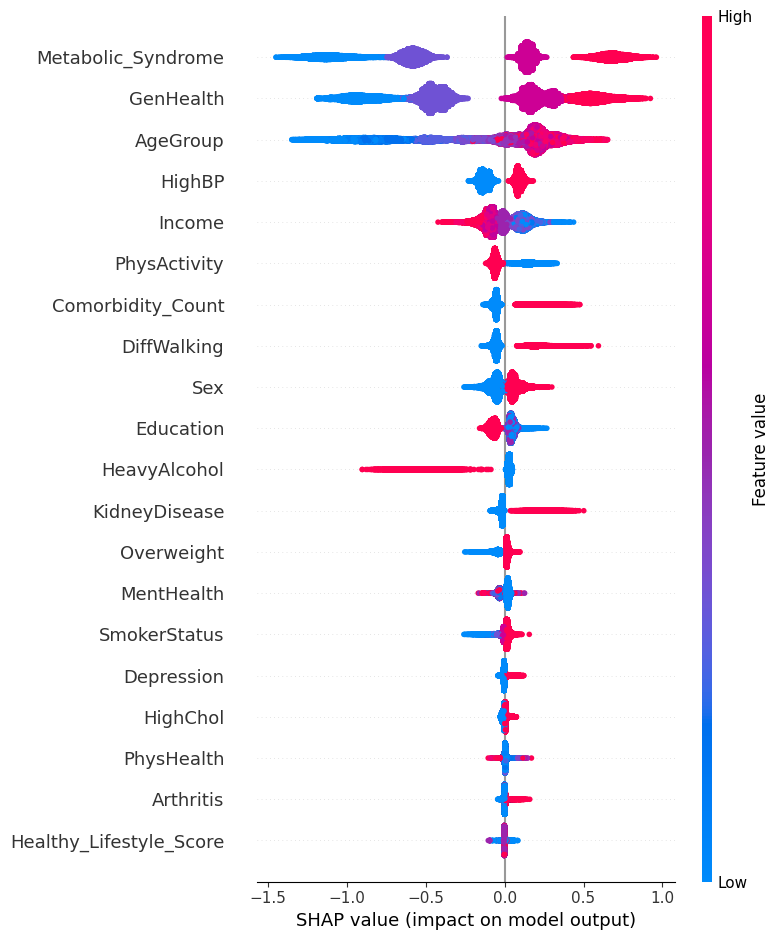

--- Processing Catboost ---


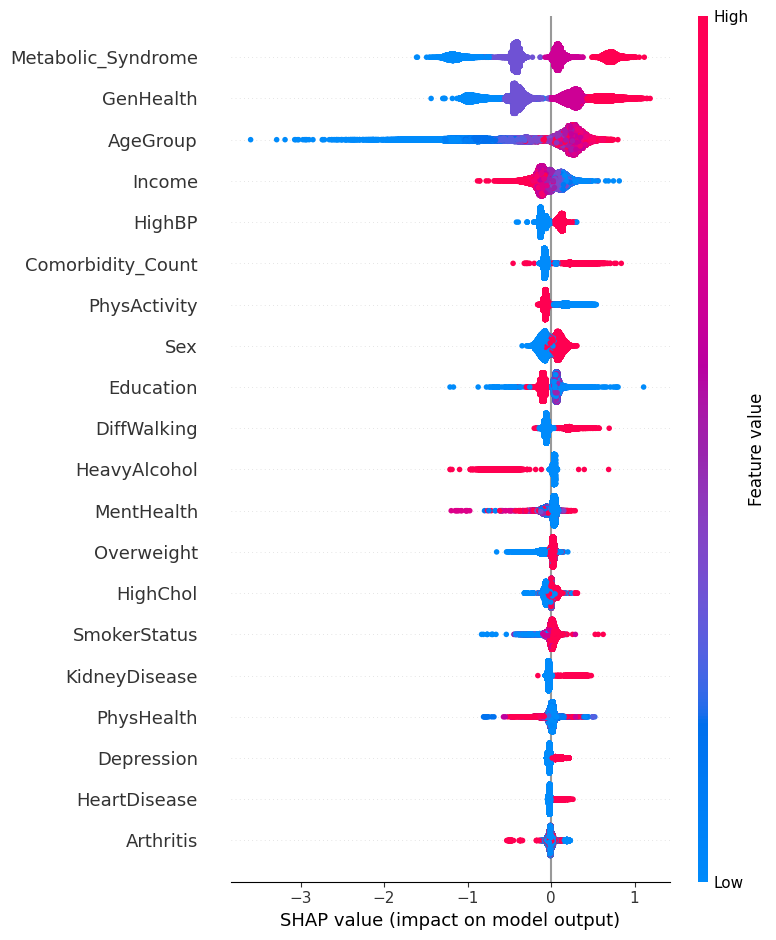

--- Processing LightGBM ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


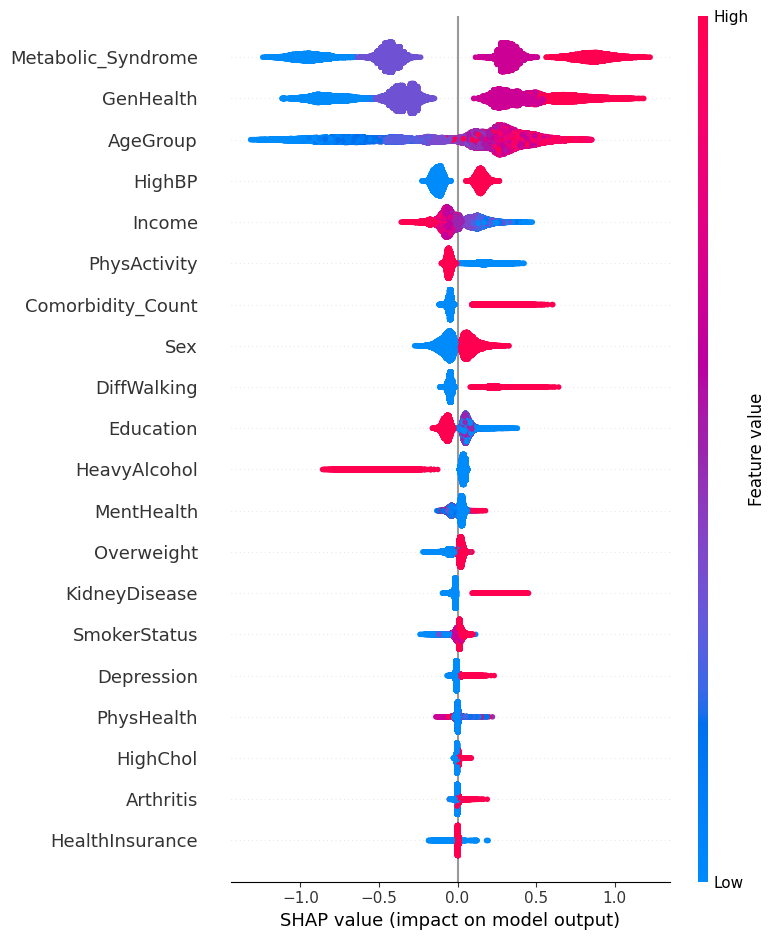

--- Processing BalancedRF ---


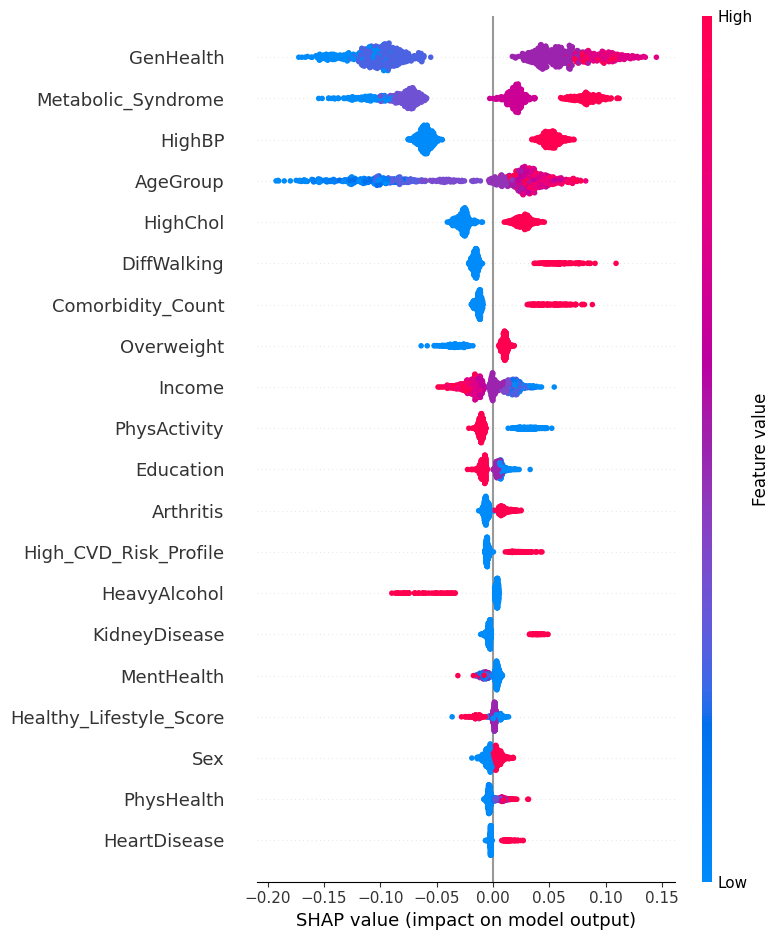

--- Processing Gradient Boosting ---


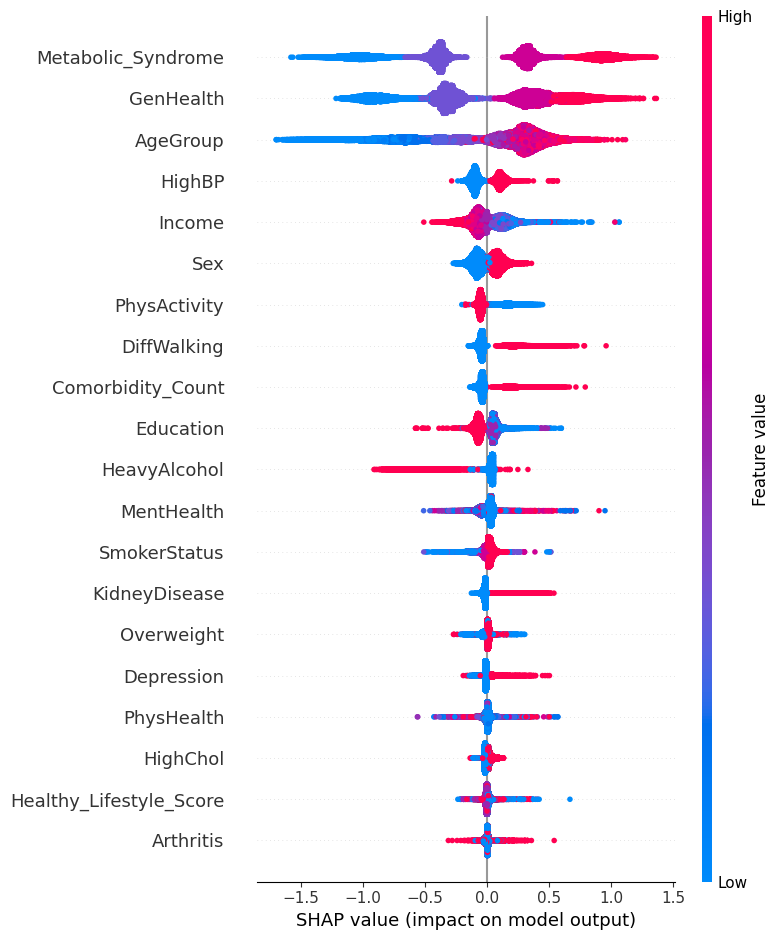

In [ ]:
# shap values for TREE-BASED MODELS

dict_shap_models = {
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'BalancedRF': balanced_rf_model,
               'Gradient Boosting': gradient_boost_model
               }


for name, model in dict_shap_models.items():
    print(f"--- Processing {name} ---")

    X_train_copy = X_train.copy()

    X_test_copy = X_test.copy()

    scaler = StandardScaler()

    X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
    X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

    model.fit(X_train_copy, y_train)

    if name == 'BalancedRF':
      X_test_sample = shap.sample(X_test_copy, 1000)
    else:
      X_test_sample = X_test_copy
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test_sample)

    if isinstance(shap_values, list):
        current_shap = shap_values[1]
    elif len(shap_values.shape) == 3:
        current_shap = shap_values[:, :, 1]
    else:
        current_shap = shap_values

    shap.summary_plot(current_shap, X_test_sample)

--- Processing Logistic Regression ---


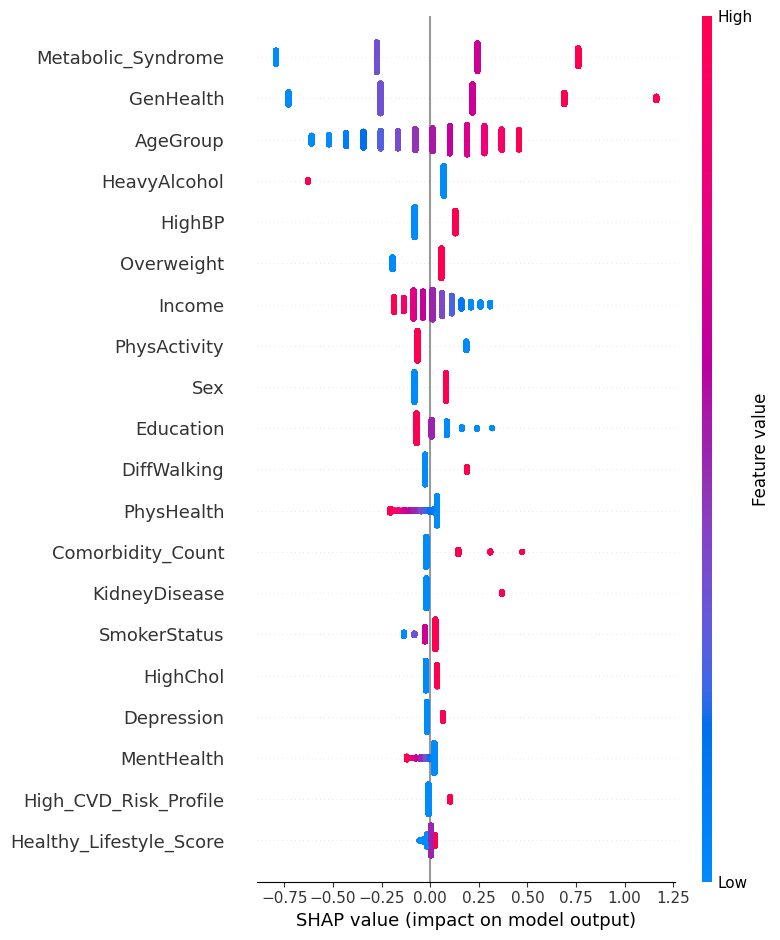

--- Processing SVM ---


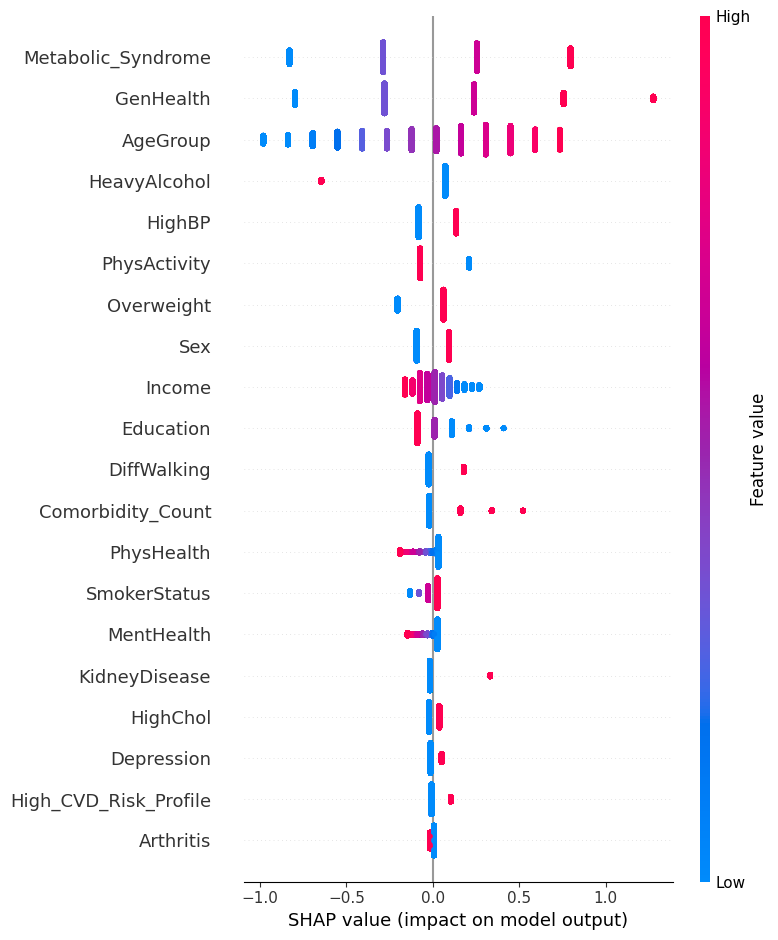

In [ ]:
# shap values for Linear-BASED MODELS

dict_linear_shap_models = {
               'Logistic Regression': log_reg_model,
               'SVM': svm_model
               }

for name, model in dict_linear_shap_models.items():
    print(f"--- Processing {name} ---")

    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    scaler = StandardScaler()
    X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
    X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

    model.fit(X_train_copy, y_train)

    explainer = shap.LinearExplainer(model, X_train_copy)

    shap_values = explainer.shap_values(X_test_copy)

    current_shap = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(current_shap, X_test_copy)

/tmp/ipykernel_62262/1364487806.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Diff_Means', y='Feature', data=feat_importance_nb, palette='coolwarm')


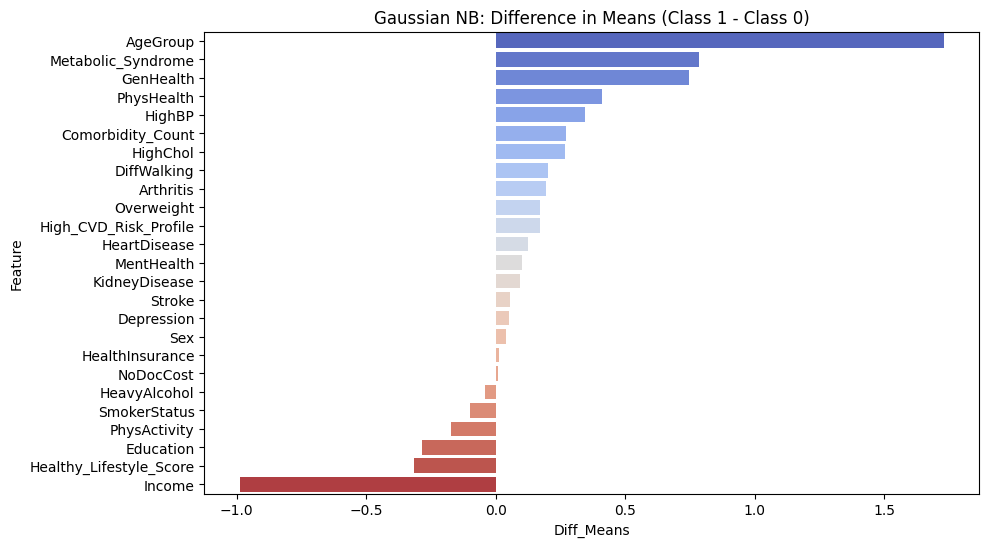

In [ ]:
# GaussianNB
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

scaler = StandardScaler()
X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

nb_gaussian_model.fit(X_train_copy, y_train)

feature_names = X_train_copy.columns
diff_means = nb_gaussian_model.theta_[1] - nb_gaussian_model.theta_[0]

feat_importance_nb = pd.DataFrame({'Feature': feature_names, 'Diff_Means': diff_means})
feat_importance_nb = feat_importance_nb.sort_values(by='Diff_Means', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Diff_Means', y='Feature', data=feat_importance_nb, palette='coolwarm')
plt.title('Gaussian NB: Difference in Means (Class 1 - Class 0)')
plt.show()

THE LEAST LOGPROB VALUE THE LEAST IMPORTANT FEATURE

/tmp/ipykernel_62262/1471967508.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Log_Prob', y='Feature', data=feat_importance_cnb, palette='coolwarm')


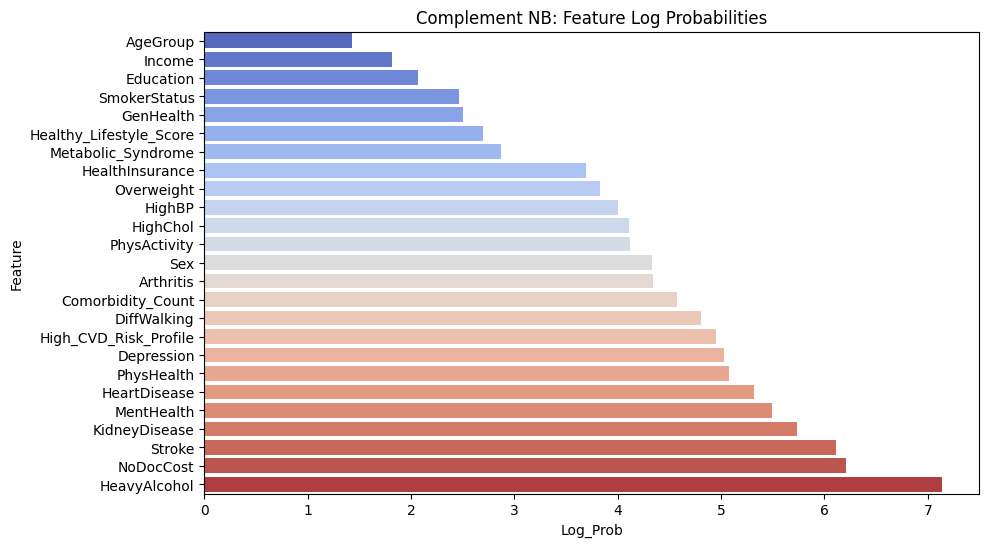

In [ ]:
# ComplementNB


X_train_copy = X_train.copy()
X_test_copy = X_test.copy()


scaler = MinMaxScaler()
X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])


nb_complement_model.fit(X_train_copy, y_train)

importance_cnb = nb_complement_model.feature_log_prob_[0]

feat_importance_cnb = pd.DataFrame({'Feature': feature_names, 'Log_Prob': importance_cnb})
feat_importance_cnb = feat_importance_cnb.sort_values(by='Log_Prob', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Log_Prob', y='Feature', data=feat_importance_cnb, palette='coolwarm')
plt.title('Complement NB: Feature Log Probabilities')
plt.show()

## STEP 15. SOFT AND HARD VOTING (ENSEMBLING OF THE MODELS)

In [19]:
 # DO SOFT/HARD VOTING

scoring_metrics_new = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1_score': make_scorer(f1_score)
    }


estimators=[('brf', balanced_rf_model),  ('svm', svm_model), ('lightgbm', lightgbm_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='soft')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

voting_soft_results = cross_validate(
    pipe, X_train, y_train.ravel(),
    cv=5,
    scoring=scoring_metrics_new
)

voting_soft_results

{'fit_time': array([53.2587409 , 47.70571685, 48.00555658, 48.0670104 , 47.10125828]),
 'score_time': array([2.07760644, 2.12879515, 2.18670821, 2.06548595, 2.75524092]),
 'test_accuracy': array([0.6863739 , 0.70987382, 0.66507797, 0.74918037, 0.71229027]),
 'test_precision': array([0.32564861, 0.34070699, 0.31518571, 0.37233389, 0.34329349]),
 'test_recall': array([0.7819561 , 0.74822466, 0.82036798, 0.68474576, 0.75108959]),
 'test_f1_score': array([0.45980829, 0.46821189, 0.45540474, 0.48237435, 0.47121373])}

FINAL RESULTS FOR SOFT VOTING ENSEMBLE

In [24]:
voting_soft_df = pd.DataFrame({
    'Accuracy': voting_soft_results['test_accuracy'],
    'Precision': voting_soft_results['test_precision'],
    'Recall': voting_soft_results['test_recall'],
    'F1-score': voting_soft_results['test_f1_score']
})

# Настройка индекса
voting_soft_df.index = [f"Fold {i+1}" for i in range(len(voting_soft_df))]

# Добавление средней строки
voting_soft_df.loc['AVERAGE'] = voting_soft_df.mean()
voting_soft_df

,Accuracy,Precision,Recall,F1-score
Fold 1,0.686374,0.325649,0.781956,0.459808
Fold 2,0.709874,0.340707,0.748225,0.468212
Fold 3,0.665078,0.315186,0.820368,0.455405
Fold 4,0.749180,0.372334,0.684746,0.482374
Fold 5,0.712290,0.343293,0.751090,0.471214
AVERAGE,0.704559,0.339434,0.757277,0.467403


FINAL RESULTS FOR HARD VOTING ENSEMBLE

In [20]:
 # HARD VOTING

scoring_metrics_new = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),# average='macro'),
        'recall': make_scorer(recall_score),# average='macro'),
        'f1_score': make_scorer(f1_score),# average='macro')
    }


estimators=[('lgbm', lightgbm_model), ('brf', balanced_rf_model),  ('svm', svm_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='hard')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

voting_hard_results = cross_validate(
    pipe, X_train, y_train.ravel(),
    cv=5,
    scoring=scoring_metrics_new
)

voting_hard_results



{'fit_time': array([45.73732686, 45.22657466, 45.34580851, 44.84344125, 47.62804198]),
 'score_time': array([2.40495634, 2.28094649, 2.26500177, 2.76309109, 2.55811119]),
 'test_accuracy': array([0.72072841, 0.7176704 , 0.70384043, 0.70697303, 0.73441331]),
 'test_precision': array([0.34813102, 0.34611879, 0.33821231, 0.33982543, 0.35969699]),
 'test_recall': array([0.72901872, 0.7354745 , 0.76823757, 0.76045198, 0.71283293]),
 'test_f1_score': array([0.47123259, 0.47071584, 0.4696596 , 0.46973776, 0.47812906])}

RESULTS OF HARD VOTING ENSEMBLE

In [25]:
voting_hard_df = pd.DataFrame({
    'Accuracy': voting_hard_results['test_accuracy'],
    'Precision': voting_hard_results['test_precision'],
    'Recall': voting_hard_results['test_recall'],
    'F1-score': voting_hard_results['test_f1_score']
})

# Настройка индекса
voting_hard_df.index = [f"Fold {i+1}" for i in range(len(voting_hard_df))]

# Добавление средней строки
voting_hard_df.loc['AVERAGE'] = voting_hard_df.mean()
voting_hard_df

,Accuracy,Precision,Recall,F1-score
Fold 1,0.720728,0.348131,0.729019,0.471233
Fold 2,0.717670,0.346119,0.735474,0.470716
Fold 3,0.703840,0.338212,0.768238,0.469660
Fold 4,0.706973,0.339825,0.760452,0.469738
Fold 5,0.734413,0.359697,0.712833,0.478129
AVERAGE,0.716725,0.346397,0.741203,0.471895


##

## STEP 16. FINAL PREDICTION AND METRICS ON THE TEST

In [21]:
## PREDICTION FOR SOFT VOTING

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


estimators=[('lgbm', lightgbm_model), ('brf', balanced_rf_model),  ('svm', svm_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='soft')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_probs = pipe.predict_proba(X_test)[:, 1]

# 2. Собираем метрики в словарь
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probs)
    ]
}

# 3. Превращаем в красивую таблицу
test_results_df = pd.DataFrame(metrics_data)

# Визуализация
print("--- Final Test Results ---")
display(test_results_df.style.format({"Value": "{:.4f}"})
        .background_gradient(cmap='Greens', subset=['Value']))

--- Final Test Results ---


,Metric,Value
0,Accuracy,0.7399
1,Precision,0.3630
2,Recall,0.6943
3,F1 Score,0.6518
4,AUC-ROC,0.7997


BEST MODEL (BALANCED RANDOM FOREST MODEL) IN TERMS OF RECALL AND ITS RESULTS

In [23]:
preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_rf_model)
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_probs = pipe.predict_proba(X_test)[:, 1]

# 2. Собираем метрики в словарь
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred,average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro'),
        roc_auc_score(y_test, y_probs)
    ]
}

# 3. Превращаем в красивую таблицу
test_results_df = pd.DataFrame(metrics_data)

# Визуализация
print("--- Final Test Results ---")
display(test_results_df.style.format({"Value": "{:.4f}"})
        .background_gradient(cmap='Greens', subset=['Value']))

--- Final Test Results ---


,Metric,Value
0,Accuracy,0.7019
1,Precision,0.6346
2,Recall,0.7257
3,F1 Score,0.6296
4,AUC-ROC,0.7983


## USING OVERSAMPLING/UNDERSAMPLING

In [ ]:
# run all the stuff with undersampling technique